Implementing KNN classifier

In [102]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [103]:
df=pd.read_csv("J:\data_cleaned.csv")
df.head()

,Survived,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,...,Parch_0,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Embarked_C,Embarked_Q,Embarked_S
0,0,22.0,7.2500,0,0,1,0,1,0,1,...,1,0,0,0,0,0,0,0,0,1
1,1,38.0,71.2833,1,0,0,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0
2,1,26.0,7.9250,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,0,0,1
3,1,35.0,53.1000,1,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,1
4,0,35.0,8.0500,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1


In [104]:
df.corr()

,Survived,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,...,Parch_0,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Embarked_C,Embarked_Q,Embarked_S
Survived,1.000000,-6.980852e-02,0.257307,0.285904,0.093349,-0.322308,0.543351,-0.543351,-0.115867,0.173076,...,-0.147408,0.134174,0.075020,0.033391,-0.053002,-0.028398,-0.026456,0.168240,0.003650,-0.149683
Age,-0.069809,1.000000e+00,0.091566,0.319916,0.006589,-0.281004,-0.084153,0.084153,0.148409,0.014570,...,0.261583,-0.147908,-0.256435,0.020239,0.076487,0.054924,0.034310,0.032024,-0.013855,-0.019336
Fare,0.257307,9.156609e-02,1.000000,0.591711,-0.118557,-0.413333,0.182333,-0.182333,-0.192190,0.133121,...,-0.237717,0.114650,0.203206,-0.009457,0.071344,0.000523,0.009918,0.269335,-0.117216,-0.162184
Pclass_1,0.285904,3.199164e-01,0.591711,1.000000,-0.288585,-0.626738,0.098013,-0.098013,-0.058470,0.125673,...,-0.008373,0.018496,0.014713,-0.042496,0.001187,-0.042496,-0.018962,0.296423,-0.155342,-0.161921
Pclass_2,0.093349,6.589145e-03,-0.118557,-0.288585,1.000000,-0.565210,0.064746,-0.064746,-0.033099,0.077469,...,-0.039091,0.062425,-0.005051,0.035908,-0.034258,-0.038324,-0.017100,-0.125416,-0.127301,0.189980
Pclass_3,-0.322308,-2.810040e-01,-0.413333,-0.626738,-0.565210,1.000000,-0.137143,0.137143,0.077316,-0.171329,...,0.039029,-0.066741,-0.008566,0.007391,0.026859,0.067804,0.030255,-0.153329,0.237449,-0.015104
Sex_female,0.543351,-8.415344e-02,0.182333,0.098013,0.064746,-0.137143,1.000000,-1.000000,-0.203203,0.179339,...,-0.247523,0.127636,0.170993,0.070383,0.020746,0.070383,0.045439,0.082853,0.074115,-0.119224
Sex_male,-0.543351,8.415344e-02,-0.182333,-0.098013,-0.064746,0.137143,-1.000000,1.000000,0.203203,-0.179339,...,0.247523,-0.127636,-0.170993,-0.070383,-0.020746,-0.070383,-0.045439,-0.082853,-0.074115,0.119224
SibSp_0,-0.115867,1.484087e-01,-0.192190,-0.058470,-0.033099,0.077316,-0.203203,0.203203,1.000000,-0.811408,...,0.420233,-0.302415,-0.215801,-0.077838,-0.062369,-0.045565,-0.049132,-0.034759,0.055398,-0.004412
SibSp_1,0.173076,1.457006e-02,0.133121,0.125673,0.077469,-0.171329,0.179339,-0.179339,-0.811408,1.000000,...,-0.223798,0.229119,0.002173,0.064787,0.081687,0.064787,0.060551,0.092043,-0.066568,-0.038742


In [105]:
x=pd.DataFrame(df, columns=['Survived','Fare','Pclass_1','Pclass_3','Sex_female','Sex_male'])
y=df['Survived']
x.shape,y.shape

((891, 6), (891,))

In [106]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.2,random_state=20)

In [107]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((178, 6), (713, 6), (178,), (713,))

In [108]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier()
KNN.fit(x_train,y_train)

KNeighborsClassifier()

In [109]:
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import f1_score

In [110]:
# function for finding k-value
def Elbow(k):
    # initializing empty list
    test_error=[]
    #Training model for every value
    for i in k:
    # instance of KNN
       clf=KNN(n_neighbors=i)
       clf.fit(x_train,y_train)
    # appending F1 scores to empty list calculated using the predictions
       tmp=clf.predict(x_test)
       temp=f1_score(tmp,y_test)
       error=1-temp
       test_error.append(error)
    return test_error


In [111]:
#Defining k range
k=range(6,10,2)

In [112]:
# calling above defined function
test=Elbow(k)

Text(0.5, 1.0, 'Elbow curve for test')

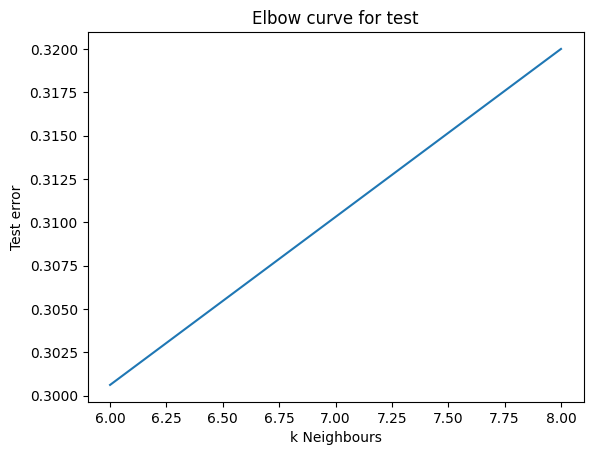

In [113]:
# plotting the curves
plt.plot(k,test)
plt.xlabel('k Neighbours')
plt.ylabel('Test error')
plt.title('Elbow curve for test')